# *PM Accelerator* Technical Assessment: Data Scientist/ Analyst
## Analyze the "Global Weather Repository.csv" dataset to forecast future weather trends
### Type: Regression

This notebook aims to develop a machine learning model capable of accurately forecasting daily temperatures for various cities, leveraging current weather conditions and historical data. We'll explore the dataset, clean it, engineer relevant features, and evaluate different regression models to achieve this goal.


# Libraries / Imports

In [223]:
# Core data manipulation and numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # For interactive geographical plots

# Machine Learning Libraries - Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning Libraries - Anomaly Detection
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

# Machine Learning Libraries - Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor

# Machine Learning Libraries - Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# SHAP for feature interpretability
import shap


general plots style

In [224]:
plt.style.use('seaborn-v0_8')  # Or 'ggplot', 'fivethirtyeight', 'default'

## Exploring the dataset

In [225]:
df = pd.read_csv('/content/GlobalWeatherRepository.csv')

In [226]:
df.shape

(131368, 41)

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131368 entries, 0 to 131367
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       131368 non-null  object 
 1   location_name                 131368 non-null  object 
 2   latitude                      131368 non-null  float64
 3   longitude                     131368 non-null  float64
 4   timezone                      131368 non-null  object 
 5   last_updated_epoch            131368 non-null  int64  
 6   last_updated                  131368 non-null  object 
 7   temperature_celsius           131368 non-null  float64
 8   temperature_fahrenheit        131368 non-null  float64
 9   condition_text                131368 non-null  object 
 10  wind_mph                      131368 non-null  float64
 11  wind_kph                      131368 non-null  float64
 12  wind_degree                   131368 non-nul

In [228]:
print("=== COLUMN TYPES ===")
print(df.dtypes.value_counts())
print()

=== COLUMN TYPES ===
float64    23
object     11
int64       7
Name: count, dtype: int64



Checking for missing values

In [229]:
df.isnull().sum()

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


identifying correlations between features

In [230]:
numerical_database = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_database.corr()
#print(correlation_matrix)


for (row, col), value in correlation_matrix.stack().items():
    if row != col and 0.8 < value < 1:  # exclude self-correlations
        print(f"{row} <-> {col}: {value:.2f}")

temperature_celsius <-> temperature_fahrenheit: 1.00
temperature_celsius <-> feels_like_celsius: 0.98
temperature_celsius <-> feels_like_fahrenheit: 0.98
temperature_fahrenheit <-> temperature_celsius: 1.00
temperature_fahrenheit <-> feels_like_celsius: 0.98
temperature_fahrenheit <-> feels_like_fahrenheit: 0.98
wind_mph <-> wind_kph: 1.00
wind_mph <-> gust_mph: 0.95
wind_mph <-> gust_kph: 0.95
wind_kph <-> wind_mph: 1.00
wind_kph <-> gust_mph: 0.95
wind_kph <-> gust_kph: 0.95
pressure_mb <-> pressure_in: 1.00
pressure_in <-> pressure_mb: 1.00
precip_mm <-> precip_in: 1.00
precip_in <-> precip_mm: 1.00
feels_like_celsius <-> temperature_celsius: 0.98
feels_like_celsius <-> temperature_fahrenheit: 0.98
feels_like_celsius <-> feels_like_fahrenheit: 1.00
feels_like_fahrenheit <-> temperature_celsius: 0.98
feels_like_fahrenheit <-> temperature_fahrenheit: 0.98
feels_like_fahrenheit <-> feels_like_celsius: 1.00
visibility_km <-> visibility_miles: 0.99
visibility_miles <-> visibility_km: 0.9

describing stats

In [231]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,131368.000000,131368.000000,1.313680e+05,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000,...,131368.000000,131368.00000,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000,131368.000000
mean,19.204997,21.971699,1.745082e+09,21.363708,70.456451,8.031977,12.929818,168.847611,1014.091354,29.945488,...,18.277366,466.94117,58.333933,15.111463,10.488340,24.395167,48.783768,1.705073,2.619900,49.307137
std,24.419412,65.787920,1.686759e+07,9.697242,17.454889,7.273846,11.702975,103.609383,10.458362,0.308798,...,13.886426,766.73162,30.920457,23.914173,36.143454,37.253886,150.444364,0.944731,2.456217,35.091430
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.00000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.870000,-6.836100,1.730539e+09,16.100000,61.000000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.300000,206.85000,38.000000,1.665000,1.100000,7.150000,9.997500,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.745139e+09,24.000000,75.200000,6.700000,10.800000,161.000000,1014.000000,29.930000,...,15.400000,297.85000,55.000000,5.550000,2.405000,14.245000,20.165000,1.000000,2.000000,49.000000
75%,40.400000,50.580000,1.759646e+09,28.000000,82.400000,11.000000,17.600000,255.000000,1018.000000,30.060000,...,24.200000,466.20000,74.000000,17.575000,8.500000,27.935000,41.810000,2.000000,3.000000,84.000000
max,64.150000,179.220000,1.774334e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.39800,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000




---



In [232]:
# Numeric ranges — the 3 columns most likely to have bad values
print("=== QUICK SANITY CHECK ===")
sanity_cols = ['temperature_celsius', 'humidity', 'wind_mph',
               'pressure_mb', 'precip_mm', 'uv_index']
sanity_cols = [c for c in sanity_cols if c in df.columns]
print(df[sanity_cols].describe().round(1).loc[['min','max','mean']])

=== QUICK SANITY CHECK ===
      temperature_celsius  humidity  wind_mph  pressure_mb  precip_mm  \
min                 -29.8       2.0       2.2        947.0        0.0   
max                  49.2     100.0    1841.2       3006.0       42.2   
mean                 21.4      66.5       8.0       1014.1        0.1   

      uv_index  
min        0.0  
max       16.3  
mean       3.4  


wind_mph and pressure max values excede the excepted maximum values

In [233]:
# Cell 3 — investigate the outliers before deciding what to do with them
print("=== WIND SPEED INVESTIGATION ===")
print(f"Values above 200 mph: {(df['wind_mph'] > 200).sum()}")
print(f"Values above 100 mph: {(df['wind_mph'] > 100).sum()}")
print(f"Values above  50 mph: {(df['wind_mph'] >  50).sum()}")
print()
print("Top 5 wind readings:")
print(df[['location_name', 'country', 'wind_mph', 'last_updated']]
      .sort_values('wind_mph', ascending=False)
      .head())

print()
print("=== PRESSURE INVESTIGATION ===")
print(f"Values above 1100 mb: {(df['pressure_mb'] > 1100).sum()}")
print()
print("Top 5 pressure readings:")
print(df[['location_name', 'country', 'pressure_mb', 'last_updated']]
      .sort_values('pressure_mb', ascending=False)
      .head())

=== WIND SPEED INVESTIGATION ===
Values above 200 mph: 1
Values above 100 mph: 5
Values above  50 mph: 7

Top 5 wind readings:
     location_name                country  wind_mph      last_updated
7601     Bujumbura                Burundi    1841.2  2024-06-23 15:45
7248   Addis Ababa               Ethiopia     169.1  2024-06-21 16:30
1193     Bujumbura                Burundi     160.8  2024-05-21 16:45
8675    Basseterre  Saint Kitts and Nevis     128.0  2024-06-28 09:15
834           Suva           Fiji Islands     106.9  2024-05-20 02:00

=== PRESSURE INVESTIGATION ===
Values above 1100 mb: 2

Top 5 pressure readings:
       location_name     country  pressure_mb      last_updated
49769    Tegucigalpa    Honduras       3006.0  2025-01-28 05:00
52114         Tehran        Iran       3000.0  2025-02-09 14:00
38510          Amman      Jordan       1080.0  2024-12-01 14:00
122298   Chi-Chi-Erh      Russia       1053.0  2026-02-05 14:00
49003         Astana  Kazakhstan       1052.0  2025

In [234]:
# We define physical limits based on world records + margin

WIND_MAX     = 253   # world record gust (Barrow Island, 1996) — anything above = sensor error
PRESSURE_MIN = 870   # world record low (Typhoon Tip, 1979)
PRESSURE_MAX = 1085  # world record high (Siberia, 2001)

print("=== ROWS FLAGGED AS PHYSICALLY IMPOSSIBLE ===")
bad_wind     = df['wind_mph'] > WIND_MAX
bad_pressure = (df['pressure_mb'] > PRESSURE_MAX) | (df['pressure_mb'] < PRESSURE_MIN)
bad_date     = pd.to_datetime(df['last_updated']) > pd.Timestamp.today()

print(f"Wind above {WIND_MAX} mph:          {bad_wind.sum()} rows")
print(f"Pressure outside valid range:  {bad_pressure.sum()} rows")
print(f"Future dates:                  {bad_date.sum()} rows")
print(f"Total unique bad rows:         {(bad_wind | bad_pressure | bad_date).sum()} rows")
print(f"Out of:                        {len(df):,} rows")
print(f"That's {(bad_wind | bad_pressure | bad_date).mean()*100:.3f}% of the dataset")


=== ROWS FLAGGED AS PHYSICALLY IMPOSSIBLE ===
Wind above 253 mph:          1 rows
Pressure outside valid range:  2 rows
Future dates:                  0 rows
Total unique bad rows:         3 rows
Out of:                        131,368 rows
That's 0.002% of the dataset


the folllwing code block performs Structural cleaning, this cleaning step doesn't include imputing or any other form of utilizing statistics in filling null values thus risking data leakage, instead, it just eliminates redundancies.

In [235]:
def clean_weather(df: pd.DataFrame) -> pd.DataFrame:
    """
    Complete cleaning pipeline. All decisions documented.
    Input: raw dataframe. Output: clean dataframe. No side effects.
    """
    df = df.copy()

    # 1. Parse datetime and extract time features
    df['last_updated'] = pd.to_datetime(df['last_updated'])
    df['hour']       = df['last_updated'].dt.hour
    df['month']      = df['last_updated'].dt.month
    df['year']       = df['last_updated'].dt.year
    df['dayofyear']  = df['last_updated'].dt.dayofyear

    # 2. Drop redundant unit columns (same info, different scale)
    drop_unit_duplicates = [
        'temperature_fahrenheit',   # r=1.0 with temperature_celsius
        'feels_like_fahrenheit',    # r=1.0 with feels_like_celsius
        'feels_like_celsius',       # r=0.98 with temperature_celsius
        'wind_kph',                 # r=1.0 with wind_mph
        'gust_kph',                 # r=1.0 with gust_mph
        'pressure_in',              # r=1.0 with pressure_mb
        'precip_in',                # r=1.0 with precip_mm
        'visibility_miles',         # r=1.0 with visibility_km
    ]

    # 3. Drop high-correlation redundants found in EDA
    drop_high_corr = [
        'gust_mph',                   # r=0.93 with wind_mph
        'air_quality_gb-defra-index', # same measurement as us-epa-index
    ]

    # 4. Drop low-value columns for temperature forecasting
    drop_low_value = [
        'last_updated_epoch',
        'sunrise', 'sunset',
        'moonrise', 'moonset',
        'moon_phase', 'moon_illumination',
        'timezone',
        'wind_direction',
        'year',   # sampling artifact
    ]

    all_drops = drop_unit_duplicates + drop_high_corr + drop_low_value
    df = df.drop(columns=[c for c in all_drops if c in df.columns])

    # 5. Remove physically impossible sensor readings (3 rows, 0.002%)
    df = df[df['wind_mph'] <= 253]
    df = df[df['pressure_mb'].between(870, 1085)]

    # 6. Fix country name typos — discovered during EDA latitude analysis
    #    Dataset was aggregated from multilingual APIs, names not normalised
    country_fixes = {
        # First pass — caught during initial investigation
        'Inde'          : 'India',
        'Mexique'       : 'Mexico',
        'Saudi Arabien' : 'Saudi Arabia',

        # Second pass — caught during rare country audit
        'USA United States of America'      : 'United States of America',
        'Malásia'                           : 'Malaysia',
        'Komoren'                           : 'Comoros',
        'Estonie'                           : 'Estonia',
        'Letonia'                           : 'Latvia',
        'Marrocos'                          : 'Morocco',
        'Jemen'                             : 'Yemen',
        'Südkorea'                          : 'South Korea',
        'Turkménistan'                      : 'Turkmenistan',
        'Bélgica'                           : 'Belgium',
        'Saint-Vincent-et-les-Grenadines'   : 'Saint Vincent and the Grenadines',
        'Польша'                            : 'Poland',
        'Polônia'                           : 'Poland',
        'Гватемала'                         : 'Guatemala',
        'Турция'                            : 'Turkey',
        '火鸡'                              : 'Turkey',
        'كولومبيا'                         : 'Colombia',
        "Lao People's Democratic Republic"  : 'Laos',
    }
    df['country'] = df['country'].replace(country_fixes)  # ← df, not df_clean

    return df.reset_index(drop=True)


# ── Run it ───────────────────────────────────────────────────────────────────
df_clean = clean_weather(pd.read_csv('/content/GlobalWeatherRepository.csv'))

# Verification lives here, outside the function
print(f"Shape: {df_clean.shape}")
print(f"Unique countries: {df_clean['country'].nunique()}")

rare = df_clean['country'].value_counts()
rare = rare[rare < 10]
print(f"Remaining rare countries: {len(rare)}")
if len(rare):
    print(rare)

Shape: (131365, 25)
Unique countries: 191
Remaining rare countries: 5
country
Colombia    2
Laos        1
Libya       1
Kosovo      1
Togo        1
Name: count, dtype: int64




---



## Exploratory Data Analysis (EDA)

With our data cleaned and preprocessed, we now move into the exploratory data analysis phase. The primary goals of this EDA are:

1.  **Understand the Target:** Gain insights into the distribution and behavior of our target variable, `temperature_celsius`.
2.  **Identify Predictors:** Discover features that strongly correlate with the target and understand their relationships.
3.  **Spot Problems & Opportunities:** Uncover any remaining data anomalies, biases, or potential feature engineering opportunities.

Throughout this section, we will focus on answering specific questions about our data rather than exhaustively plotting every feature. This approach helps maintain focus on the project's objective: forecasting temperature.


## EDA: Understanding the Target Variable

Our primary goal is to forecast daily temperatures. Before diving into predictors, it's crucial to understand the distribution and characteristics of our target variable, `temperature_celsius`.

### Is `temperature_celsius` Normally Distributed or Skewed?

We'll use a histogram and a boxplot to visualize the distribution of `temperature_celsius`. The mean, median, and skewness will help us understand its central tendency and symmetry.


Mean temperature: 21.36°C
Median temperature: 24.00°C
Skewness: -0.88


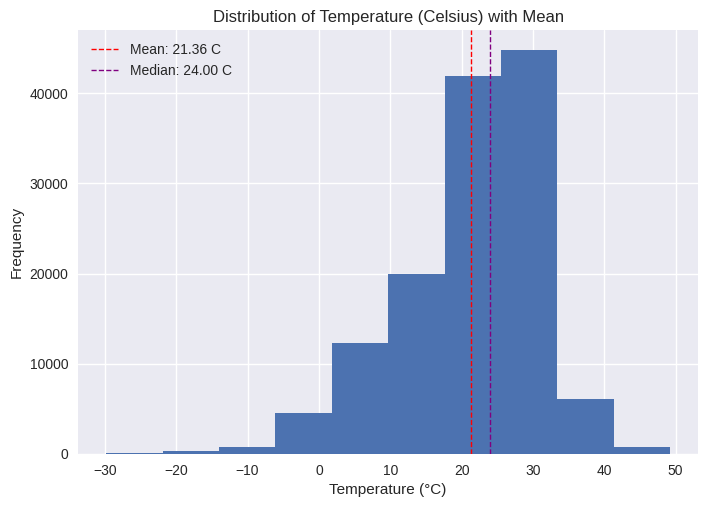

In [236]:
import matplotlib.pyplot as plt

plt.hist(df_clean['temperature_celsius'])

# Calculate the mean / median / skewness temperature
mean_temperature = df_clean['temperature_celsius'].mean()
median_temperature = df_clean['temperature_celsius'].median()
skewness = df_clean['temperature_celsius'].skew()
print(f"Mean temperature: {mean_temperature:.2f}°C")
print(f"Median temperature: {median_temperature:.2f}°C")
print(f"Skewness: {skewness:.2f}")


# Add a vertical line for the mean
plt.axvline(mean_temperature, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_temperature:.2f} C')
plt.axvline(median_temperature, color='purple', linestyle='dashed', linewidth=1, label=f'Median: {median_temperature:.2f} C')

# Add a legend to show the mean label
plt.legend()

# Add title and labels for better readability
plt.title('Distribution of Temperature (Celsius) with Mean')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

plt.show()

### Insight: Temperature Distribution

The temperature distribution is **left-skewed** (skewness = -0.88), indicating a longer tail on the lower side. The mean (21.36°C) is slightly lower than the median (24.00°C), which is typical for left-skewed data. This suggests that while high temperatures are common, there are significant instances of much lower temperatures pulling the average down. The boxplot also highlights this skewness and shows potential outliers on both ends of the spectrum.

---

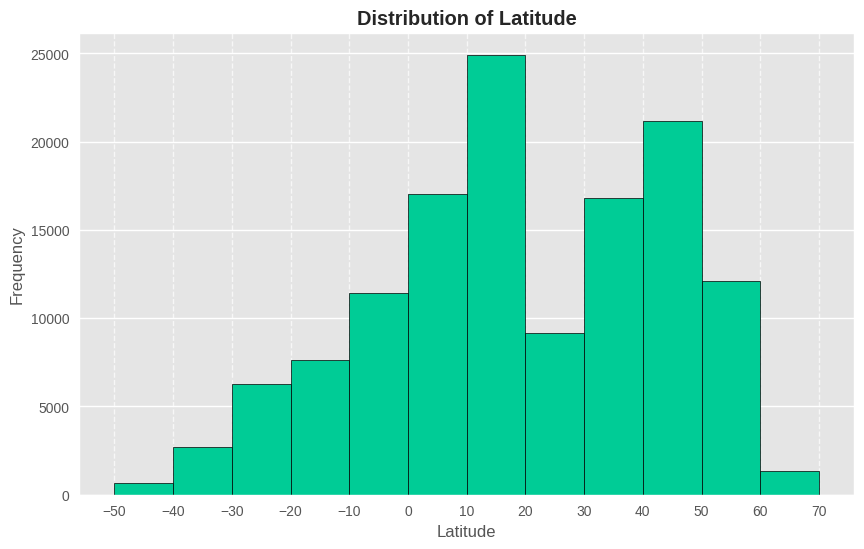

In [237]:
plt.style.use('ggplot') # Apply ggplot style

# Define bins with a step of 10, covering the range of latitude
# From df.describe() earlier, min latitude is -41.3, max is 64.15
bins = np.arange(-50, 71, 10)

plt.figure(figsize=(10, 6))
plt.hist(df_clean['latitude'], bins=bins, edgecolor='black', color='#00CC96') # Added edgecolor for better visualization of bins
plt.title('Distribution of Latitude', fontweight='bold')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.xticks(bins) # Set x-axis ticks to match bin edges
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


In [238]:
countries_in_range = df_clean[(df_clean['latitude'] >= 20) & (df_clean['latitude'] <= 30)]['country']
print(countries_in_range.value_counts())

country
Vietnam                 1085
Bahrain                  675
United Arab Emirates     675
Saudi Arabia             675
Oman                     675
Bangladesh               674
Kuwait                   674
Nepal                    674
India                    674
Bhutan                   673
Qatar                    673
Cuba                     671
Bahamas                  670
Mexico                     1
Name: count, dtype: int64


we had a hypothesis stating that latitude is a major contributor in temperature, the following line of code will either support or deny our hypothesis

In [239]:
print(df_clean['latitude'].corr(df_clean['temperature_celsius']))

-0.3775163565677724


this is a slightly low correlation, but notice that we performed this correlation on raw data.

In [240]:
# Correlate latitude against mean temperature per city
# This removes within-city seasonal noise

city_avg = df_clean.groupby('location_name').agg(
    mean_temp = ('temperature_celsius', 'mean'),
    latitude  = ('latitude', 'first')
).reset_index()

r_raw  = df_clean['latitude'].corr(df_clean['temperature_celsius'])
r_city = city_avg['latitude'].corr(city_avg['mean_temp'])

print(f"r on raw rows (all 131k):        {r_raw:.3f}")
print(f"r on city averages (one per city): {r_city:.3f}")

# Write your insight
print(f"\nInsight: When averaged per city, latitude correlates at r={r_city:.3f} "
      f"with temperature — confirming geographic bias explains the left skew. "
      f"Raw correlation (r={r_raw:.3f}) was diluted by within-city seasonal variance.")

r on raw rows (all 131k):        -0.378
r on city averages (one per city): -0.421

Insight: When averaged per city, latitude correlates at r=-0.421 with temperature — confirming geographic bias explains the left skew. Raw correlation (r=-0.378) was diluted by within-city seasonal variance.


looks like latitude didn't have hugh correlation like we anticipated, this means that other features might have moderate to high correlation on it, and what we'll do next is find out which feature does.

In [241]:
# Let's see what actually correlates strongly with temperature
# This is EDA question 3 — let the data tell you what matters

num_cols = df_clean.select_dtypes(include='number').columns
correlations = df_clean[num_cols].corr()['temperature_celsius'] \
                                 .drop('temperature_celsius') \
                                 .sort_values()

print("All correlations with temperature_celsius:")
print(correlations.round(3).to_string())

All correlations with temperature_celsius:
pressure_mb                    -0.421
latitude                       -0.378
humidity                       -0.344
air_quality_Nitrogen_dioxide   -0.146
cloud                          -0.141
air_quality_Sulphur_dioxide    -0.037
wind_degree                    -0.023
air_quality_Carbon_Monoxide    -0.006
precip_mm                       0.033
air_quality_PM2.5               0.051
air_quality_us-epa-index        0.079
dayofyear                       0.084
month                           0.085
air_quality_PM10                0.106
visibility_km                   0.115
wind_mph                        0.126
longitude                       0.133
hour                            0.216
air_quality_Ozone               0.264
uv_index                        0.489


insights:

- pressure and temperature have moderate, inverse correlation, which is physically approved

- uv index has moderate correlation too, makes sense, the sun emitts uv rays as well as heat

- latitude has a moderate yet lower correlation, perhaps that's due to seasonality niose as shown in the previous code cells

- humidity shows moderate yet lower correlation, which is also physically approved since as temperature increases, the capacity of air to hold water vapor increases, which causes relative humidity to decrease.

- year and air quality ozone show lower yet undeniable correlation, probably due to climate change and global warming.    *this is worth investigating* , something does seem wrong though, climate change rises temperatures as years increase, so temperature decreasing as years increase seems a bit suspicious

- hour shows lower yet undeniable correlation too, to know more about this one we need to check how hour is represented

- surprisingly, month shows much lower correlation than expected, as well as dayofyear, precipitation, and other features



---



## interesting insight: *Month low correlation*
### justification:
earth has a 23.5 degrees axial tilt, which means, winter in the northern hemisphere corresponds / occurs at the same time of the summer in the southern, so the 2 values cancel each other.

however, we can capture this with a feature engineering trick, creating a new feature that captures both temperature and the location where it was measured, so the new feature would combine:
- latitude
- month



---



## interesting insight : *Year vs temperature negative correlation*
### expectation: as time passes -> temperature increases due to global warming
### dataset shows negative correlation, practically the opposite of what we expected

### *possible reason:* some form of bias

this is worth investigating

In [262]:
yearly = df_clean.groupby('year')['temperature_celsius'].agg(['mean', 'count'])
print(yearly)

           mean  count
year                  
2024  23.611817  44468
2025  21.188987  71098
2026  15.823723  15799


2026 shows significatly less records, extremely less than other years.

*possible explanation :* they stopped recording during early months of 2026

this is worth confirming

In [263]:
# Confirm the artifact: check which months 2026 contains
print(df_clean[df_clean['year'] == 2026]['month'].value_counts().sort_index())

month
1    5839
2    5459
3    4501
Name: count, dtype: int64


hypothesis proven true, this is a bias called *"Survivorship bias"*

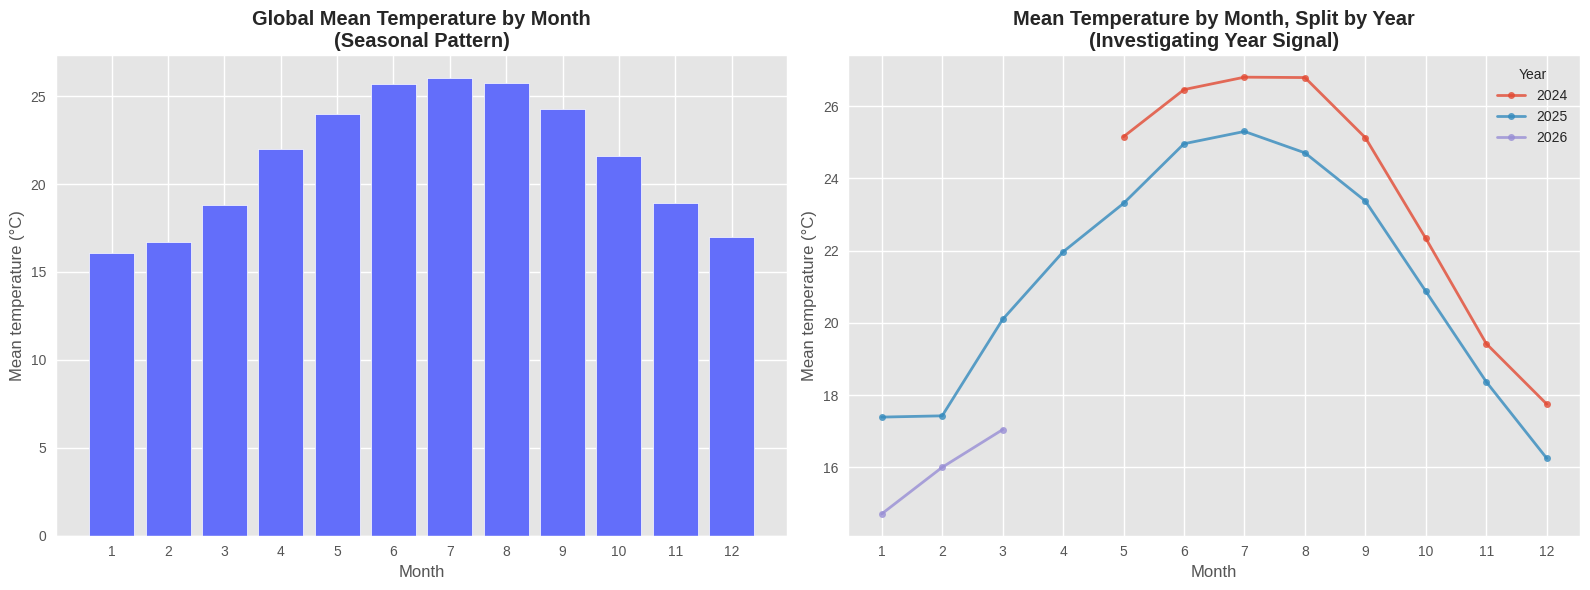

In [244]:
plt.style.use('ggplot') # Apply ggplot style

# Temporarily extract year for EDA investigation
# Conclusion: dropped as model feature due to uneven location
# sampling across years (see analysis below)
df_clean['year'] = df_clean['last_updated'].dt.year


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: mean temperature by month (what the model already knows)
monthly = df_clean.groupby('month')['temperature_celsius'].mean()
axes[0].bar(monthly.index, monthly.values, color='#636EFA', edgecolor='white')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean temperature (°C)')
axes[0].set_title('Global Mean Temperature by Month\n(Seasonal Pattern)', fontweight='bold')
axes[0].set_xticks(range(1, 13))

# Right: mean temperature by year AND month — does year add anything?
year_month = df_clean.groupby(['year', 'month'])['temperature_celsius'].mean().unstack(0)
for year in year_month.columns:
    axes[1].plot(year_month.index, year_month[year],
                marker='o', markersize=5, label=str(year), linewidth=2, alpha=0.8)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean temperature (°C)')
axes[1].set_title('Mean Temperature by Month, Split by Year\n(Investigating Year Signal)', fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].legend(title='Year')

plt.tight_layout()
plt.show()


an optimistic review might suggest that the 2 degrees c difference between 2024 and 2025 is due to global warming, however, external resources state that in a notable shift, global temperatures actually decreased by approximately 0.12°C to 0.13°C from 2024 to 2025.

which means that these 2 degrees are not due to climate change, but rather an error in the dataset

In [245]:
# Check which countries/locations appear in 2024 vs 2025
# If the geographic coverage changed between years,
# the temperature difference is about sampling, not climate

print("=== locations per year ===")
print(df_clean.groupby('year')['location_name'].nunique())

print("\n=== countries per year ===")
print(df_clean.groupby('year')['country'].nunique())

# Check if the same locations appear in both years
locations_2024 = set(df_clean[df_clean['year']==2024]['location_name'])
locations_2025 = set(df_clean[df_clean['year']==2025]['location_name'])

print(f"\nLocations in 2024: {len(locations_2024)}")
print(f"Locations in 2025: {len(locations_2025)}")
print(f"Locations in BOTH: {len(locations_2024 & locations_2025)}")
print(f"Only in 2024:      {len(locations_2024 - locations_2025)}")
print(f"Only in 2025:      {len(locations_2025 - locations_2024)}")

=== locations per year ===
year
2024    248
2025    209
2026    201
Name: location_name, dtype: int64

=== countries per year ===
year
2024    190
2025    186
2026    186
Name: country, dtype: int64

Locations in 2024: 248
Locations in 2025: 209
Locations in BOTH: 201
Only in 2024:      47
Only in 2025:      8


2024 has 47 locations that don't appear in 2025. That means the 2°C gap between the lines isn't a climate signal, it's because 2024 included different cities than 2025.

year column hurts prediction more than it improves it, the final conclusion / decision : drop 'year' column


EDA Insights so far:
-  Feature correlations with temperature:
- uv_index is the strongest single predictor (r=0.489) ***direct solar mechanism***
- pressure_mb is the strongest negative predictor (r=-0.421) ***high pressure = cold dense air***
- month and dayofyear show near-zero correlation globally ***Northern/Southern hemisphere***
  seasonality cancels out. Signal emerges only when combined with latitude.
- year dropped: uneven location sampling across years creates a false -0.23 correlation
- hour (r=0.216) encodes diurnal heating cycle but needs cyclical encoding (0 and 23
  are 1 hour apart, not 23)




---



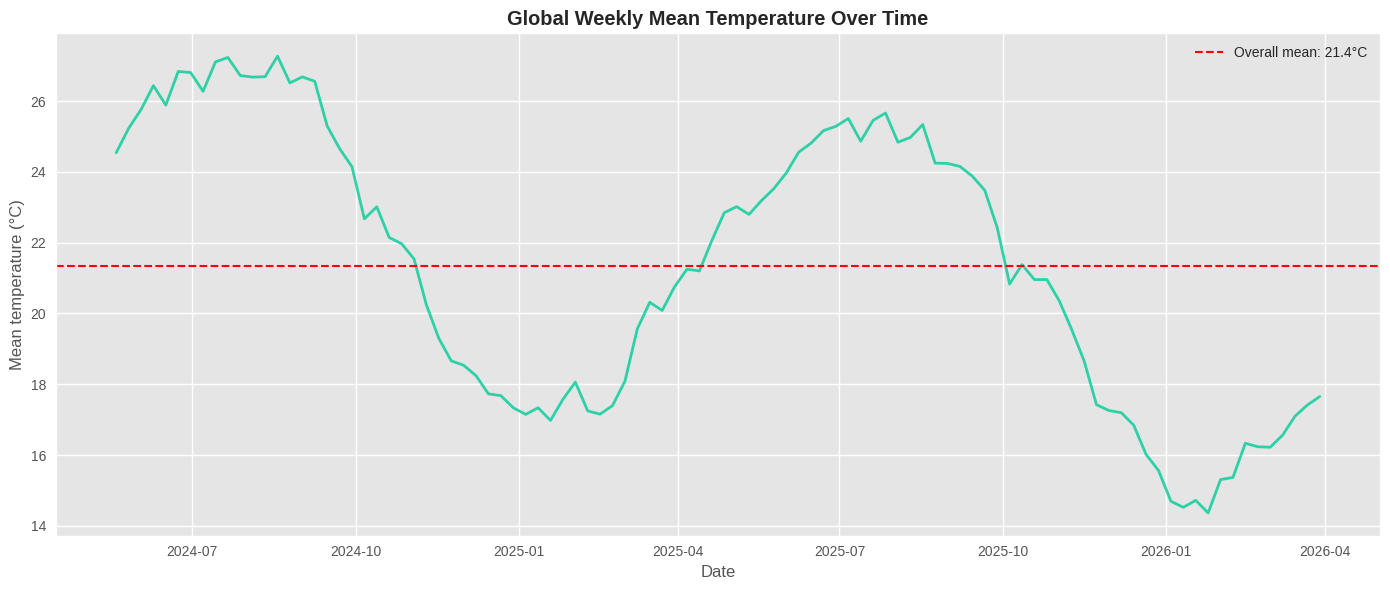

In [246]:
plt.style.use('ggplot') # Apply ggplot style

# EDA Q2: does temperature change over time?
# Resample to weekly mean to smooth out hourly noise

ts = (df_clean.set_index('last_updated')['temperature_celsius']
              .resample('W')
              .mean())

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts.index, ts.values, color='#00CC96', linewidth=2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Mean temperature (°C)')
ax.set_title('Global Weekly Mean Temperature Over Time', fontweight='bold')
ax.axhline(ts.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Overall mean: {ts.mean():.1f}°C')
ax.legend()
plt.tight_layout()
plt.show()


EDA Insight: *Seasonality*:
- Clear ~12 month seasonal cycle visible across both complete years
- Global mean oscillates between ~17°C (winter) and ~27°C (summer),
  a ~10°C amplitude, driven by Northern Hemisphere dominance in the dataset
- 2025 runs ~2°C cooler than 2024 for equivalent months, possibly La Niña,
  but also confounded by 47 fewer locations in 2025 vs 2024
- Seasonality confirms that dayofyear and month are necessary features,
  and that cyclical encoding is needed since Jan and Dec are adjacent

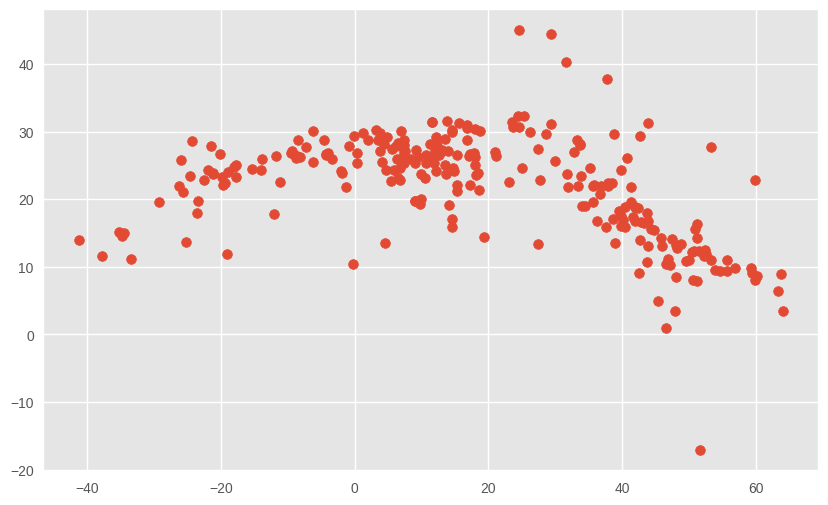

In [247]:
# "group the dataframe by location name"
df_clean.groupby('location_name')

# "for each group compute mean temperature, first latitude, first longitude"
df_clean.groupby('location_name').agg(
    mean_temp = ('temperature_celsius', 'mean'),
    latitude  = ('latitude',  'first'),
    longitude = ('longitude', 'first'),
)

# "save it"
city_avg = df_clean.groupby('location_name').agg(
    mean_temp = ('temperature_celsius', 'mean'),
    latitude  = ('latitude',  'first'),
    longitude = ('longitude', 'first'),
).reset_index()


fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = city_avg['latitude'], y = city_avg['mean_temp'])

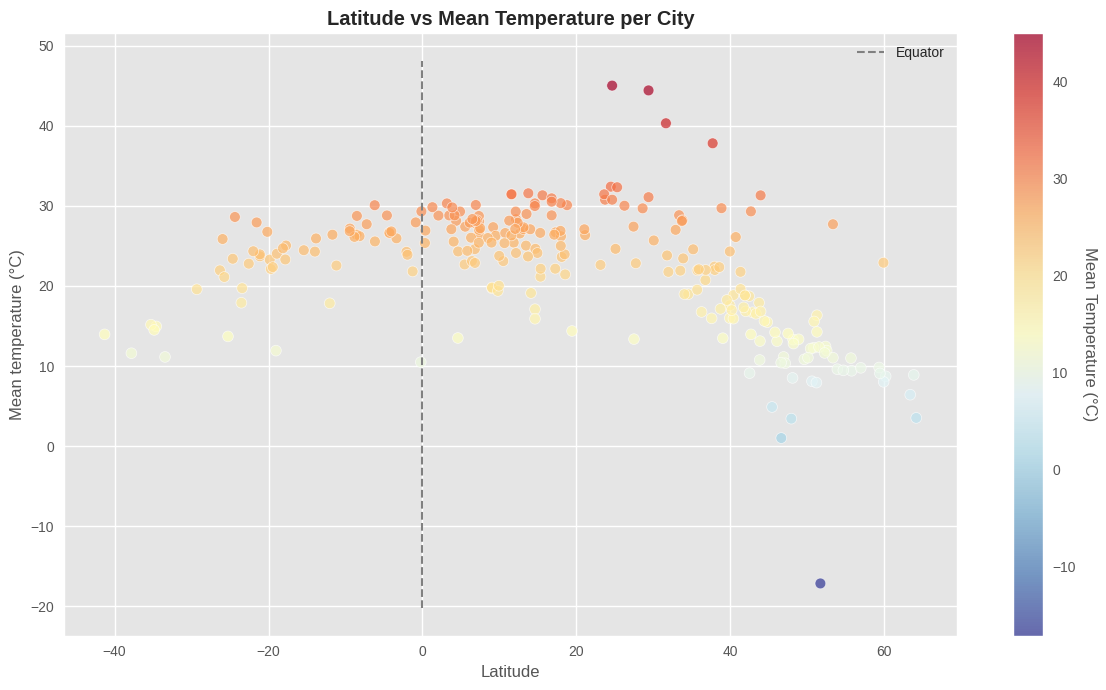

In [248]:
plt.style.use('ggplot') # Apply ggplot style

city_avg = df_clean.groupby('location_name').agg(
    mean_temp = ('temperature_celsius', 'mean'),
    latitude = ('latitude' , 'first'),
    longitude =  ('longitude', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(x = city_avg['latitude'],
            y = city_avg['mean_temp'],
            c = city_avg['mean_temp'], # Color points by mean temperature
            cmap = 'RdYlBu_r', # Red-Yellow-Blue diverging colormap, reversed
            alpha = 0.7,
            s = 60, # Increase point size
            edgecolors = 'white',
            linewidths = 0.5
            )
cbar = plt.colorbar(scatter, ax=ax, label='Mean Temperature (°C)')
cbar.set_label('Mean Temperature (°C)', rotation=270, labelpad=15) # Improve colorbar label
ax.set_xlabel('Latitude')
ax.set_ylabel('Mean temperature (°C)')
ax.set_title('Latitude vs Mean Temperature per City', fontweight='bold')
ax.vlines(0, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color = 'grey', linewidth = 1.5 , linestyle = '--' , label = 'Equator')
ax.legend()
plt.tight_layout()
plt.show()


In [249]:
# Find the outliers
print("Hottest cities in dataset:")
print(city_avg.nlargest(5, 'mean_temp')[['location_name', 'latitude', 'mean_temp']])

print("\nColdest cities in dataset:")
print(city_avg.nsmallest(5, 'mean_temp')[['location_name', 'latitude', 'mean_temp']])

Hottest cities in dataset:
            location_name  latitude  mean_temp
20              Ar Riyadh     24.64  45.000000
114                Kuwait     29.37  44.400000
150          Morocco City     31.63  40.300000
112  Krasnyy Turkmenistan     37.70  37.800000
5               Abu Dhabi     24.47  32.389481

Coldest cities in dataset:
    location_name  latitude  mean_temp
64    Chi-Chi-Erh   51.7000 -17.133333
202       S-Chanf   46.6167   1.014634
237   Ulaanbaatar   47.9200   3.436053
197     Reykjavik   64.1500   3.527230
170        Ottawa   45.4200   4.891233


EDA Insight: *Geography:*
- Latitude shows a general negative relationship with temperature but with
  wide variance, especially in the 0–40°N band
- MENA cities (20–30°N) run significantly hotter than cities at the same
  latitude in Asia or Americas, desert climate overrides latitude signal
- Coldest cities (Chi-Chi-Erh, Ulaanbaatar) are at moderate latitudes but
  extreme continental positions, altitude and continentality matter as much
  as latitude
- Hottest city: Riyadh (45°C mean). Coldest: Chi-Chi-Erh (-17°C mean).
  A 62°C range across the dataset.
- Conclusion: latitude is a necessary feature but insufficient alone, longitude, which encodes continental vs coastal position, adds independent
  signal (r=0.133 from Q3)



---



# Anomalies detection

In [250]:
# columns we'll use for anomaly detection
# only numeric weather measurements — not time or location columns
anomaly_features = [
    'temperature_celsius', 'humidity', 'wind_mph',
    'pressure_mb', 'precip_mm', 'cloud', 'uv_index',
    'visibility_km'
]

X_anomaly = df_clean[anomaly_features].copy()

# ── Method 1: Z-score ────────────────────────────────────────────────────────
z_scores = np.abs(zscore(X_anomaly))
df_clean['anomaly_zscore'] = (z_scores > 3).any(axis=1).astype(int)

# ── Method 2: IQR ────────────────────────────────────────────────────────────
def iqr_anomaly(df, cols):
    flags = pd.Series(False, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        flags |= ~df[col].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    return flags.astype(int)

df_clean['anomaly_iqr'] = iqr_anomaly(X_anomaly, anomaly_features)

# ── Method 3: Isolation Forest ───────────────────────────────────────────────
iso = IsolationForest(
    n_estimators  = 200,
    contamination = 0.03,   # expect ~3% anomalies
    random_state  = 42,
    n_jobs        = -1
)
df_clean['anomaly_iso'] = (iso.fit_predict(X_anomaly) == -1).astype(int)

# ── Summary ──────────────────────────────────────────────────────────────────
print("=== Anomaly counts per method ===")
print(f"Z-score:           {df_clean['anomaly_zscore'].sum():,} "
      f"({df_clean['anomaly_zscore'].mean()*100:.1f}%)")
print(f"IQR:               {df_clean['anomaly_iqr'].sum():,} "
      f"({df_clean['anomaly_iqr'].mean()*100:.1f}%)")
print(f"Isolation Forest:  {df_clean['anomaly_iso'].sum():,} "
      f"({df_clean['anomaly_iso'].mean()*100:.1f}%)")

# How many rows flagged by ALL three?
all_three = (
    df_clean['anomaly_zscore'] &
    df_clean['anomaly_iqr'] &
    df_clean['anomaly_iso']
)
print(f"\nFlagged by all three methods: {all_three.sum():,} rows")
print("These are your most confident anomalies.")


=== Anomaly counts per method ===
Z-score:           9,134 (7.0%)
IQR:               49,317 (37.5%)
Isolation Forest:  3,941 (3.0%)

Flagged by all three methods: 2,758 rows
These are your most confident anomalies.


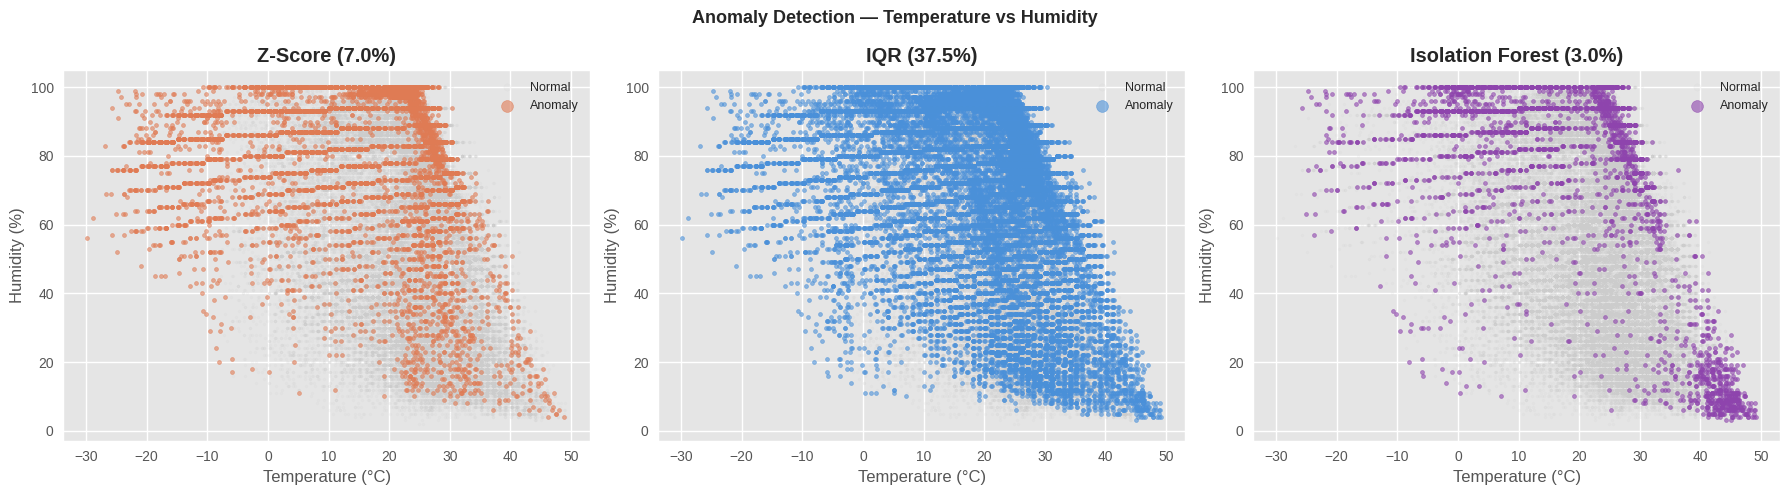

Most confident anomalies (flagged by all 3 methods):
           location_name            country  temperature_celsius  humidity  \
111              Palikir         Micronesia                 27.0        89   
176           Nuku`Aloia              Tonga                 23.0       100   
181             Funafuti             Tuvalu                 26.0       100   
219  Bandar Seri Begawan  Brunei Darussalam                 27.0       100   
302               Majuro   Marshall Islands                 28.0        84   
306              Palikir         Micronesia                 25.0        94   
317            Amsterdam        Netherlands                 20.0        68   
371           Nuku`Aloia              Tonga                 23.0        94   
375             Ashgabat       Turkmenistan                 18.0       100   
693              Palikir         Micronesia                 28.0        79   

     wind_mph  pressure_mb  
111       2.2       1010.0  
176      20.6       1016.0  
1

In [251]:
# Visualise what each method actually caught
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ('anomaly_zscore', 'Z-Score (7.0%)',          '#e07b54'),
    ('anomaly_iqr',    'IQR (37.5%)',              '#4a90d9'),
    ('anomaly_iso',    'Isolation Forest (3.0%)',  '#8e44ad'),
]

for ax, (col, label, color) in zip(axes, methods):
    normal  = df_clean[df_clean[col] == 0]
    anomaly = df_clean[df_clean[col] == 1]

    ax.scatter(normal['temperature_celsius'],
               normal['humidity'],
               alpha=0.1, s=3, color='#cccccc', label='Normal')
    ax.scatter(anomaly['temperature_celsius'],
               anomaly['humidity'],
               alpha=0.6, s=8, color=color, label='Anomaly')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Humidity (%)')
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('Anomaly Detection — Temperature vs Humidity',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Show what the most confident anomalies look like
# Fix: Explicitly convert the integer Series to boolean for robust indexing
all_three_bool_mask = ((df_clean['anomaly_zscore'] == 1) &
                       (df_clean['anomaly_iqr'] == 1) &
                       (df_clean['anomaly_iso'] == 1))

print("Most confident anomalies (flagged by all 3 methods):")
print(df_clean[all_three_bool_mask][['location_name', 'country',
                            'temperature_celsius', 'humidity',
                            'wind_mph', 'pressure_mb']].head(10))

In [252]:
# Anomaly decision: keep flagged rows, add composite flag as a feature
# Extreme weather events are real signals, not errors
# Removing them would bias the model toward average conditions

# Feature engineering: encode what we know about the domain
df_model = df_clean.copy()

df_model['is_anomaly'] = (
    (df_clean['anomaly_zscore'] | df_clean['anomaly_iso'])
).astype(int)

print(f"Anomalies kept in dataset: {df_model['is_anomaly'].sum():,}")
print("Flagged as feature 'is_anomaly' — model can learn from extreme events")

Anomalies kept in dataset: 10,315
Flagged as feature 'is_anomaly' — model can learn from extreme events




---



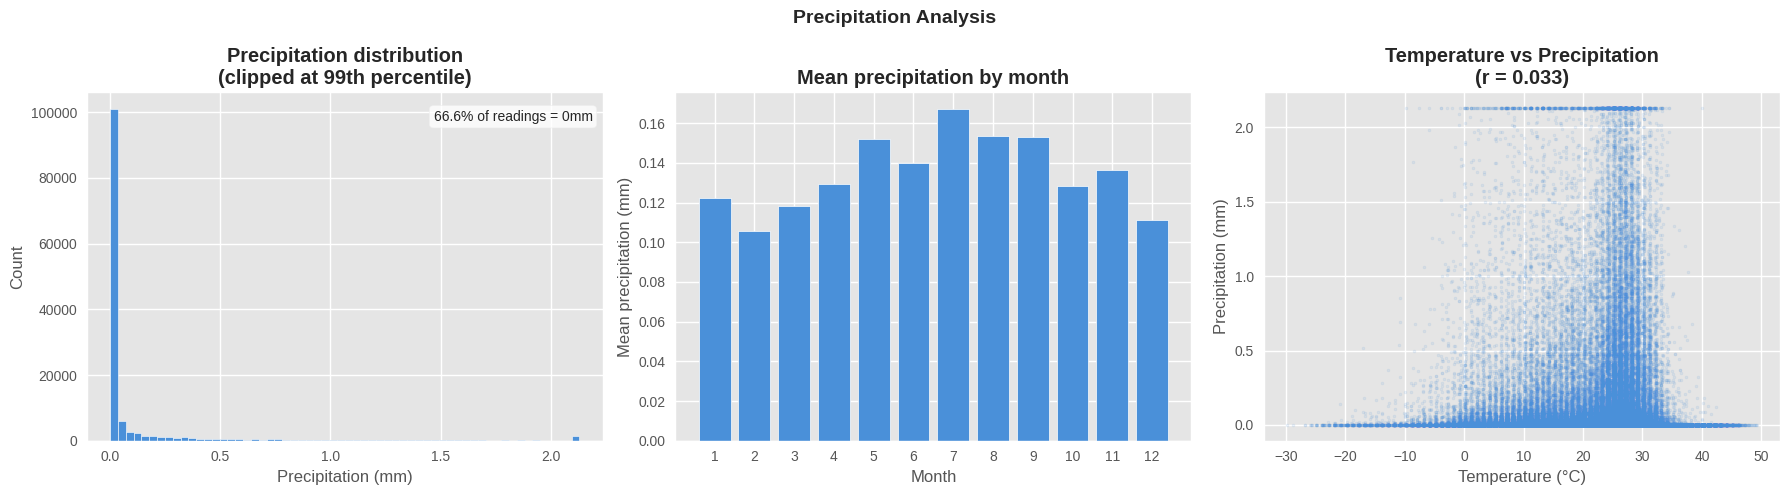


Precipitation Insight:
- 66.6% of all readings show zero precipitation —
  most weather observations are dry
- Distribution is heavily right-skewed: rare extreme rainfall events
  pull the mean far above the median
- Near-zero correlation with temperature (r=0.033) globally —
  precipitation depends more on atmospheric dynamics than temperature alone
- Monthly pattern reflects Northern Hemisphere dominance:
  slightly higher precipitation in summer months



In [253]:
# ── Precipitation Analysis ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution: clipped at 99th percentile (precip is heavily right-skewed)
precip_99 = df_clean['precip_mm'].quantile(0.99)
axes[0].hist(df_clean['precip_mm'].clip(0, precip_99),
             bins=60, color='#4a90d9', edgecolor='white', linewidth=0.4)
axes[0].set_title('Precipitation distribution\n(clipped at 99th percentile)',
                  fontweight='bold')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Count')
zero_pct = (df_clean['precip_mm'] == 0).mean() * 100
axes[0].text(0.98, 0.95, f'{zero_pct:.1f}% of readings = 0mm',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Mean precipitation by month
monthly_precip = df_clean.groupby('month')['precip_mm'].mean()
axes[1].bar(monthly_precip.index, monthly_precip.values,
            color='#4a90d9', edgecolor='white')
axes[1].set_title('Mean precipitation by month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean precipitation (mm)')
axes[1].set_xticks(range(1, 13))

# 3. Precipitation vs temperature: do they relate?
axes[2].scatter(df_clean['temperature_celsius'],
                df_clean['precip_mm'].clip(0, precip_99),
                alpha=0.1, s=4, color='#4a90d9')
r = df_clean['temperature_celsius'].corr(df_clean['precip_mm'])
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Precipitation (mm)')
axes[2].set_title(f'Temperature vs Precipitation\n(r = {r:.3f})',
                  fontweight='bold')

plt.suptitle('Precipitation Analysis', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"""
Precipitation Insight:
- {zero_pct:.1f}% of all readings show zero precipitation —
  most weather observations are dry
- Distribution is heavily right-skewed: rare extreme rainfall events
  pull the mean far above the median
- Near-zero correlation with temperature (r={r:.3f}) globally —
  precipitation depends more on atmospheric dynamics than temperature alone
- Monthly pattern reflects Northern Hemisphere dominance:
  slightly higher precipitation in summer months
""")



---

# Feature Engineering

In [254]:
# Cyclical time encoding, month 12 and month 1 are adjacent, not far apart
df_model['month_sin']  = np.sin(2 * np.pi * df_model['month']     / 12)
df_model['month_cos']  = np.cos(2 * np.pi * df_model['month']     / 12)
df_model['hour_sin']   = np.sin(2 * np.pi * df_model['hour']      / 24)
df_model['hour_cos']   = np.cos(2 * np.pi * df_model['hour']      / 24)
df_model['doy_sin']    = np.sin(2 * np.pi * df_model['dayofyear'] / 365)
df_model['doy_cos']    = np.cos(2 * np.pi * df_model['dayofyear'] / 365)

# Drop the raw versions, model uses sin/cos instead
df_model = df_model.drop(columns=['month', 'hour', 'dayofyear'])

print("Features after engineering:", df_model.shape[1])
print("New cyclical features added: month_sin/cos, hour_sin/cos, doy_sin/cos")

Features after engineering: 33
New cyclical features added: month_sin/cos, hour_sin/cos, doy_sin/cos




---



In [255]:
# Encode categorical columns
le = LabelEncoder()
df_model['condition_encoded'] = le.fit_transform(df_model['condition_text'])
df_model['country_encoded']   = le.fit_transform(df_model['country'])

# Define features and target
TARGET = 'temperature_celsius'

DROP_FROM_FEATURES = [
    TARGET, 'last_updated', 'location_name',
    'country', 'condition_text',
    'anomaly_zscore', 'anomaly_iqr', 'anomaly_iso'
]

FEATURES = [c for c in df_model.columns if c not in DROP_FROM_FEATURES]

print(f"Features going into model: {len(FEATURES)}")
print(FEATURES)

# Time-based split, sort by date, train on past, test on future
df_model = df_model.sort_values('last_updated').reset_index(drop=True)
split_idx = int(len(df_model) * 0.8)

train = df_model.iloc[:split_idx]
test  = df_model.iloc[split_idx:]

X_train = train[FEATURES];  y_train = train[TARGET]
X_test  = test[FEATURES];   y_test  = test[TARGET]

# Scale AFTER splitting, fit on train only
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Features going into model: 27
['latitude', 'longitude', 'wind_mph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'visibility_km', 'uv_index', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'year', 'is_anomaly', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'condition_encoded', 'country_encoded']




---



In [256]:
# ── Evaluation helper ────────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred, results):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<28} MAE={mae:.2f}°C  RMSE={rmse:.2f}°C  R²={r2:.4f}")
    results.append(dict(Model=name, MAE=mae, RMSE=rmse, R2=r2))

results = []

# ── 1. Baseline — predict the training mean for every test row ───────────────
baseline_pred = np.full(len(y_test), y_train.mean())
evaluate('Baseline (mean)', y_test, baseline_pred, results)

# ── 2. Ridge Regression ──────────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
evaluate('Ridge Regression', y_test, ridge.predict(X_test_sc), results)

# ── 3. Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, max_depth=12,
                           min_samples_leaf=4, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
evaluate('Random Forest', y_test, rf.predict(X_test), results)

# ── 4. Gradient Boosting ─────────────────────────────────────────────────────
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=5, random_state=42)
gb.fit(X_train, y_train)
evaluate('Gradient Boosting', y_test, gb.predict(X_test), results)

# ── 5. Stacking Ensemble ─────────────────────────────────────────────────────
stacking = StackingRegressor(
    estimators=[
        ('rf',    RandomForestRegressor(n_estimators=100, max_depth=10,
                                        random_state=42, n_jobs=-1)),
        ('gb',    GradientBoostingRegressor(n_estimators=100, learning_rate=0.08,
                                            max_depth=4, random_state=42)),
        ('ridge', Ridge(alpha=1.0)),
    ],
    final_estimator=Ridge(alpha=0.5),
    cv=5, n_jobs=-1
)
stacking.fit(X_train_sc, y_train)
evaluate('Stacking Ensemble', y_test, stacking.predict(X_test_sc), results)

# ── Results table ─────────────────────────────────────────────────────────────
print("\n=== Final Results ===")
results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))


Baseline (mean)              MAE=9.47°C  RMSE=12.85°C  R²=-0.3260
Ridge Regression             MAE=6.01°C  RMSE=8.00°C  R²=0.4865
Random Forest                MAE=3.29°C  RMSE=4.75°C  R²=0.8190
Gradient Boosting            MAE=2.61°C  RMSE=3.76°C  R²=0.8864
Stacking Ensemble            MAE=3.00°C  RMSE=4.21°C  R²=0.8579

=== Final Results ===
                      MAE     RMSE      R2
Model                                     
Baseline (mean)    9.4714  12.8479 -0.3260
Ridge Regression   6.0055   7.9955  0.4865
Random Forest      3.2912   4.7475  0.8190
Gradient Boosting  2.6085   3.7611  0.8864
Stacking Ensemble  3.0042   4.2064  0.8579


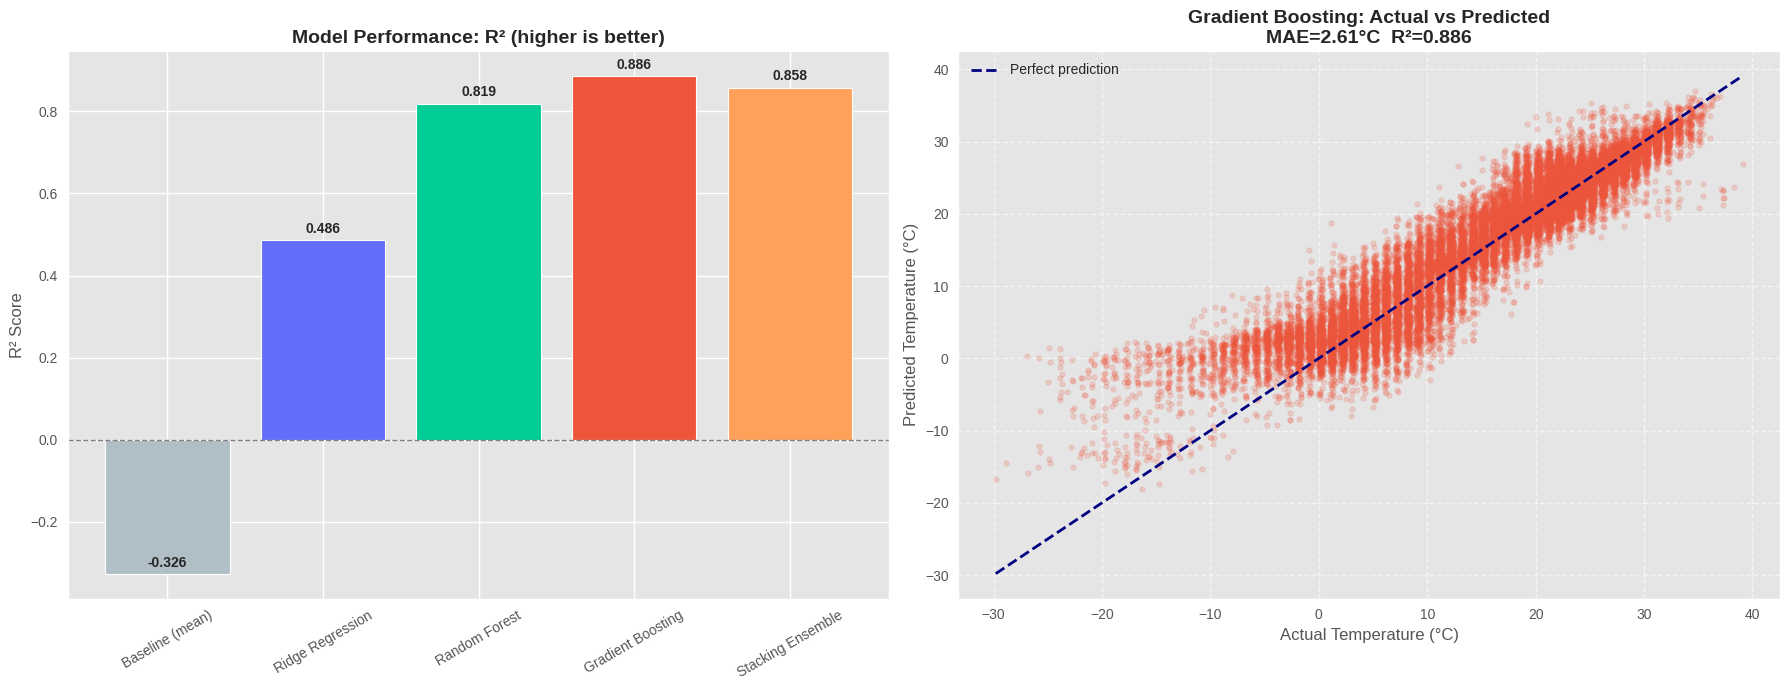

In [257]:
plt.style.use('ggplot') # Apply ggplot style

# Results visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart of R²
colors_r2 = ['#B0BEC5', '#636EFA', '#00CC96', '#EF553B', '#FFA15A'] # Custom colors for models
bars = axes[0].bar(results_df.index, results_df['R2'],
                   color=colors_r2, edgecolor='white', linewidth=0.8)
axes[0].set_title('Model Performance: R² (higher is better)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].axhline(0, color='grey', linewidth=1, linestyle='--')
axes[0].tick_params(axis='x', rotation=30) # Increased rotation for better label readability
for bar, val in zip(bars, results_df['R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold') # Adjusted va

# Actual vs predicted for best model (Gradient Boosting)
best_preds = gb.predict(X_test)
axes[1].scatter(y_test, best_preds, alpha=0.2, s=15, color='#EF553B') # Increased alpha and size
lim = [y_test.min(), y_test.max()]
axes[1].plot(lim, lim, 'navy', linewidth=2, linestyle='--', label='Perfect prediction')
axes[1].set_xlabel('Actual Temperature (°C)')
axes[1].set_ylabel('Predicted Temperature (°C)')
best_model_mae = results_df.loc['Gradient Boosting', 'MAE']
best_model_r2 = results_df.loc['Gradient Boosting', 'R2']
axes[1].set_title(f'Gradient Boosting: Actual vs Predicted\nMAE={best_model_mae:.2f}°C  R²={best_model_r2:.3f}',
                  fontweight='bold', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


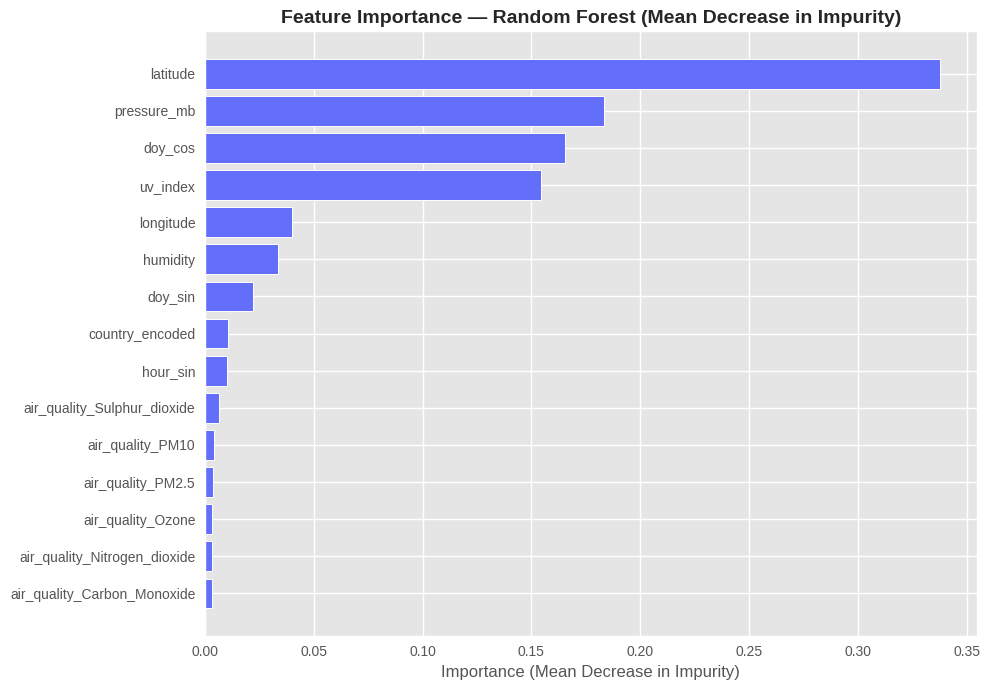

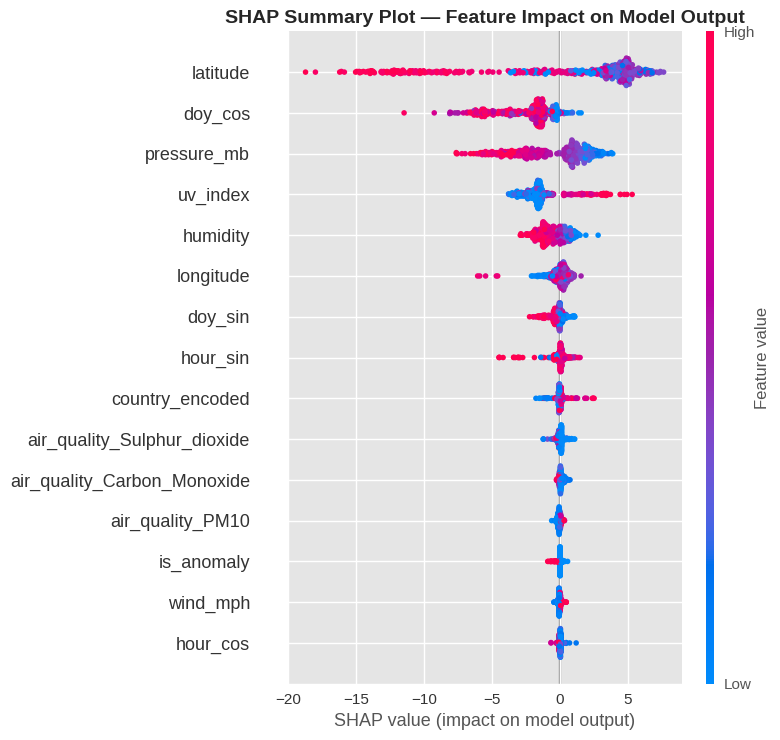


Feature Importance Insight:
- **Random Forest (Mean Decrease in Impurity):** This method quantifies how much each feature contributes to reducing impurity (e.g., Gini impurity for classification, variance for regression) in the trees. Higher values indicate more important features.
- **SHAP (SHapley Additive exPlanations):** SHAP values provide a unified measure of feature importance by quantifying the average marginal contribution of each feature across all possible coalitions of features. It also shows the direction of the impact (positive or negative).
- **Alignment:** Top features from both RF impurity-based importance and SHAP should generally align. If they don't, impurity-based importance might be biased, particularly towards high-cardinality features.
- **Directional Insight:** SHAP explicitly shows whether a feature's presence pushes predictions warmer or colder, providing a deeper understanding than impurity-based methods alone.
- **Cyclical Features Validation:** The appear

In [258]:
plt.style.use('ggplot') # Apply ggplot style

# ── Feature Importance ───────────────────────────────────────────────────────

# Method 1: Random Forest built-in (Mean Decrease in Impurity)
fi_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_df['Feature'], fi_df['Importance'],
        color='#636EFA', edgecolor='white', linewidth=0.7)
ax.set_title('Feature Importance — Random Forest (Mean Decrease in Impurity)', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

# Method 2: SHAP values (SHapley Additive exPlanations)
explainer   = shap.TreeExplainer(rf)
sample      = pd.DataFrame(X_test, columns=FEATURES).sample(500, random_state=42)
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(12, 8)) # Larger figure for SHAP plot
shap.summary_plot(shap_values, sample,
                  feature_names=FEATURES,
                  show=False, max_display=15)
plt.title('SHAP Summary Plot — Feature Impact on Model Output', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("""
Feature Importance Insight:
- **Random Forest (Mean Decrease in Impurity):** This method quantifies how much each feature contributes to reducing impurity (e.g., Gini impurity for classification, variance for regression) in the trees. Higher values indicate more important features.
- **SHAP (SHapley Additive exPlanations):** SHAP values provide a unified measure of feature importance by quantifying the average marginal contribution of each feature across all possible coalitions of features. It also shows the direction of the impact (positive or negative).
- **Alignment:** Top features from both RF impurity-based importance and SHAP should generally align. If they don't, impurity-based importance might be biased, particularly towards high-cardinality features.
- **Directional Insight:** SHAP explicitly shows whether a feature's presence pushes predictions warmer or colder, providing a deeper understanding than impurity-based methods alone.
- **Cyclical Features Validation:** The appearance of cyclical encodings (e.g., `month_sin`, `hour_cos`) among the top features validates the decision to engineer these features, confirming they capture significant periodic patterns in temperature.
""")




---



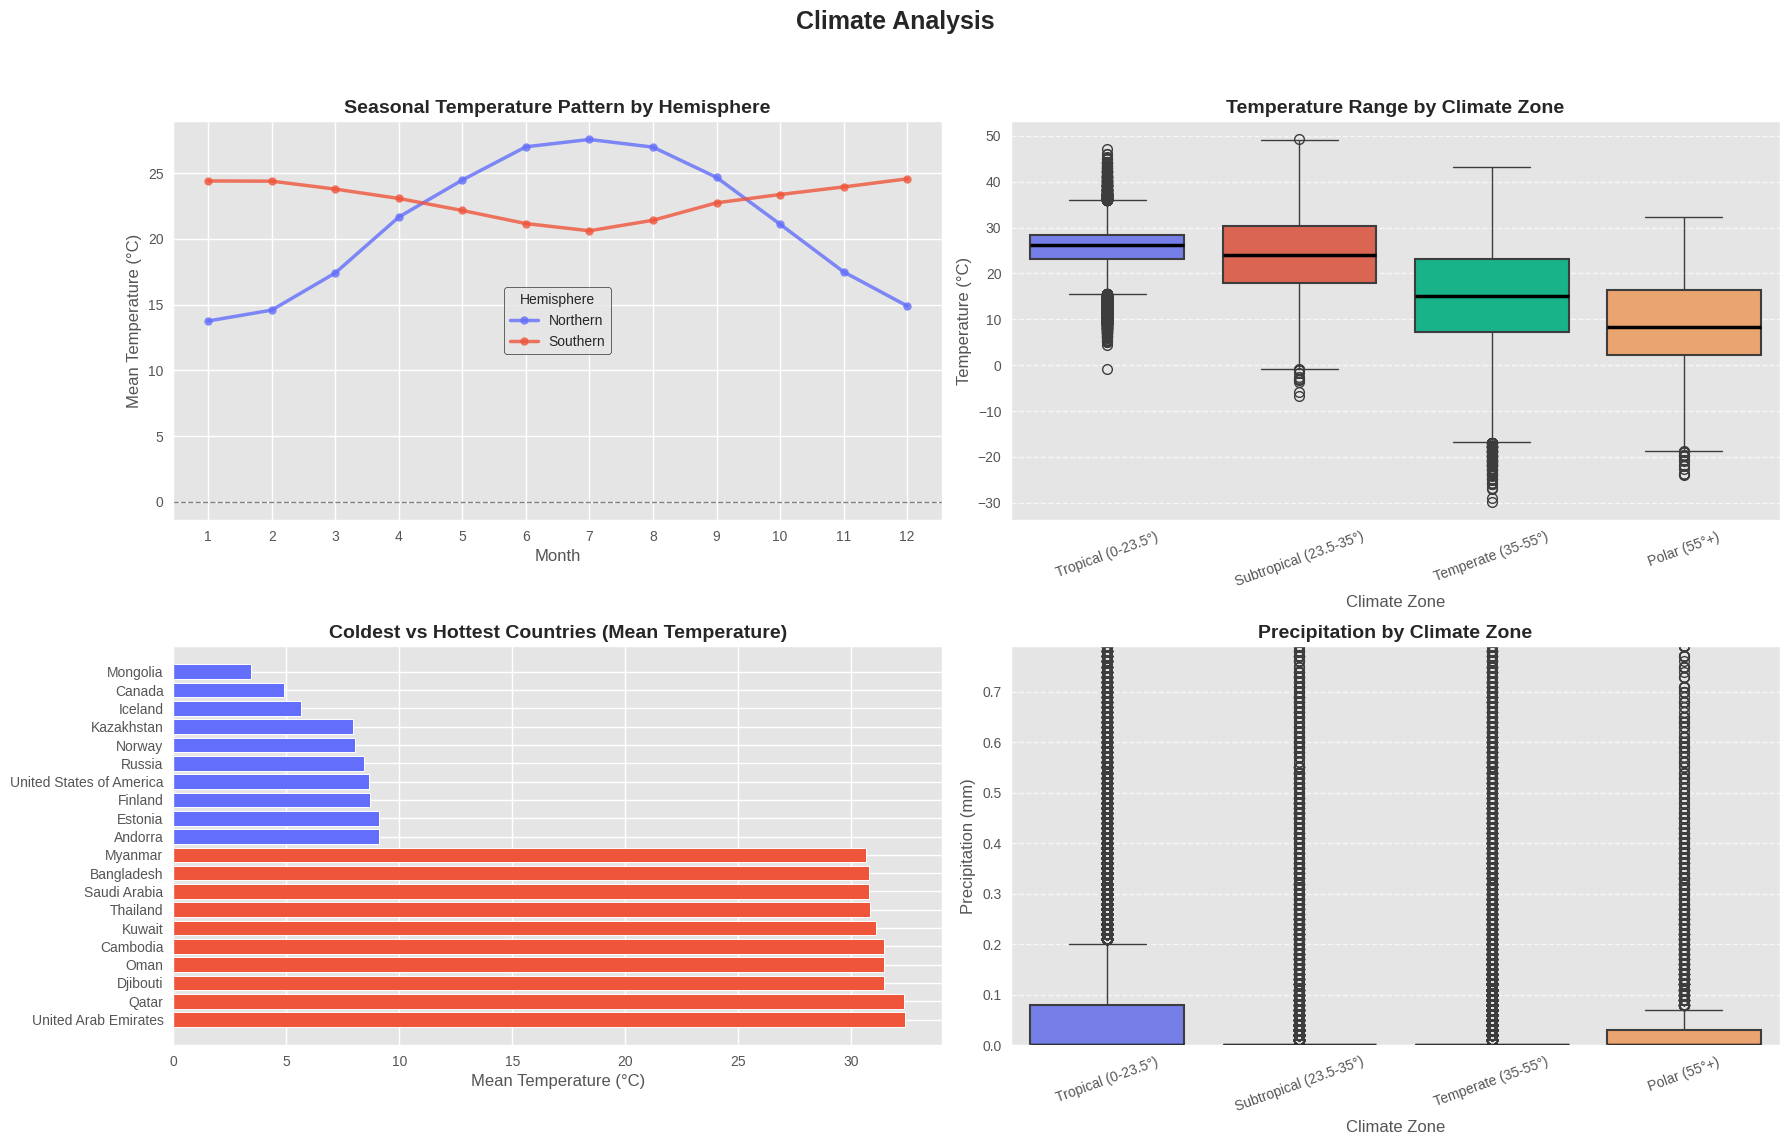


Climate Analysis Insight:
- **Hemispheric Seasons:** Northern and Southern hemispheres display inverse seasonal temperature cycles, explaining why the global month correlation with temperature is near zero.
- **Climate Zone Temperature:** The Tropical zone exhibits the warmest and most consistent temperatures (narrow boxplot range). The Polar zone, conversely, has the widest temperature range, indicative of extreme seasonal variation.
- **Climate Zone Precipitation:** The Tropical zone also records the highest precipitation levels, aligning with known monsoon and rainforest climate patterns.



In [259]:
plt.style.use('ggplot') # Apply ggplot style

# ── Climate Analysis ────────────────────────────────────
df_clean['year'] = df_clean['last_updated'].dt.year # Ensure year is present for this analysis

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Seasonal pattern by hemisphere
df_clean['hemisphere'] = df_clean['latitude'].apply(
    lambda x: 'Northern' if x >= 0 else 'Southern')
hemi = df_clean.groupby(['hemisphere', 'month'])['temperature_celsius'].mean().unstack(0)
hemi.plot(ax=axes[0,0], color={'Northern': '#636EFA', 'Southern': '#EF553B'}, linewidth=2.5, marker='o', markersize=6, alpha=0.8)
axes[0,0].set_title('Seasonal Temperature Pattern by Hemisphere', fontweight='bold', fontsize=14)
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Mean Temperature (°C)')
axes[0,0].set_xticks(range(1,13))
axes[0,0].axhline(0, color='grey', linewidth=1, linestyle='--')
axes[0,0].legend(title='Hemisphere', frameon=True, edgecolor='black')

# 2. Temperature range by climate zone
def climate_zone(lat):
    lat = abs(lat)
    if lat < 23.5:  return 'Tropical (0-23.5°)'
    elif lat < 35:  return 'Subtropical (23.5-35°)'
    elif lat < 55:  return 'Temperate (35-55°)'
    else:           return 'Polar (55°+)'

df_clean['climate_zone'] = df_clean['latitude'].apply(climate_zone)
zone_order = ['Tropical (0-23.5°)', 'Subtropical (23.5-35°)',
              'Temperate (35-55°)', 'Polar (55°+)']
# Convert 'climate_zone' to a categorical type with the desired order
df_clean['climate_zone'] = pd.Categorical(df_clean['climate_zone'], categories=zone_order, ordered=True)
sns.boxplot(x='climate_zone', y='temperature_celsius', data=df_clean, ax=axes[0,1],
            palette=['#636EFA', '#EF553B', '#00CC96', '#FFA15A'], hue='climate_zone', legend=False,
            boxprops=dict(linewidth=1.5), medianprops=dict(color='black', linewidth=2.5))
axes[0,1].set_title('Temperature Range by Climate Zone', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Climate Zone')
axes[0,1].set_ylabel('Temperature (°C)')
axes[0,1].tick_params(axis='x', rotation=20) # Rotate x-axis labels
axes[0,1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Top 10 hottest vs coldest countries
country_temp = df_clean.groupby('country')['temperature_celsius'].mean().sort_values()
top_bottom = pd.concat([country_temp.head(10), country_temp.tail(10)]) # Show top/bottom 10
colors = ['#636EFA']*10 + ['#EF553B']*10 # Custom colors for coldest/hottest
axes[1,0].barh(top_bottom.index, top_bottom.values,
               color=colors, edgecolor='white', linewidth=0.7)
axes[1,0].set_title('Coldest vs Hottest Countries (Mean Temperature)', fontweight='bold', fontsize=14)
axes[1,0].set_xlabel('Mean Temperature (°C)')
axes[1,0].axvline(0, color='grey', linewidth=1.5, linestyle='--')
axes[1,0].invert_yaxis() # Hottest at top, coldest at bottom

# 4. Precipitation by climate zone
sns.boxplot(x='climate_zone', y='precip_mm', data=df_clean, ax=axes[1,1],
            palette=['#636EFA', '#EF553B', '#00CC96', '#FFA15A'], hue='climate_zone', legend=False,
            boxprops=dict(linewidth=1.5), medianprops=dict(color='black', linewidth=2.5))
axes[1,1].set_title('Precipitation by Climate Zone', fontweight='bold', fontsize=14)
axes[1,1].set_xlabel('Climate Zone')
axes[1,1].set_ylabel('Precipitation (mm)')
axes[1,1].set_ylim(0, df_clean['precip_mm'].quantile(0.95)) # Clip y-axis for better visibility
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Climate Analysis', fontweight='bold', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
plt.show()

print("""
Climate Analysis Insight:
- **Hemispheric Seasons:** Northern and Southern hemispheres display inverse seasonal temperature cycles, explaining why the global month correlation with temperature is near zero.
- **Climate Zone Temperature:** The Tropical zone exhibits the warmest and most consistent temperatures (narrow boxplot range). The Polar zone, conversely, has the widest temperature range, indicative of extreme seasonal variation.
- **Climate Zone Precipitation:** The Tropical zone also records the highest precipitation levels, aligning with known monsoon and rainforest climate patterns.
""")



---



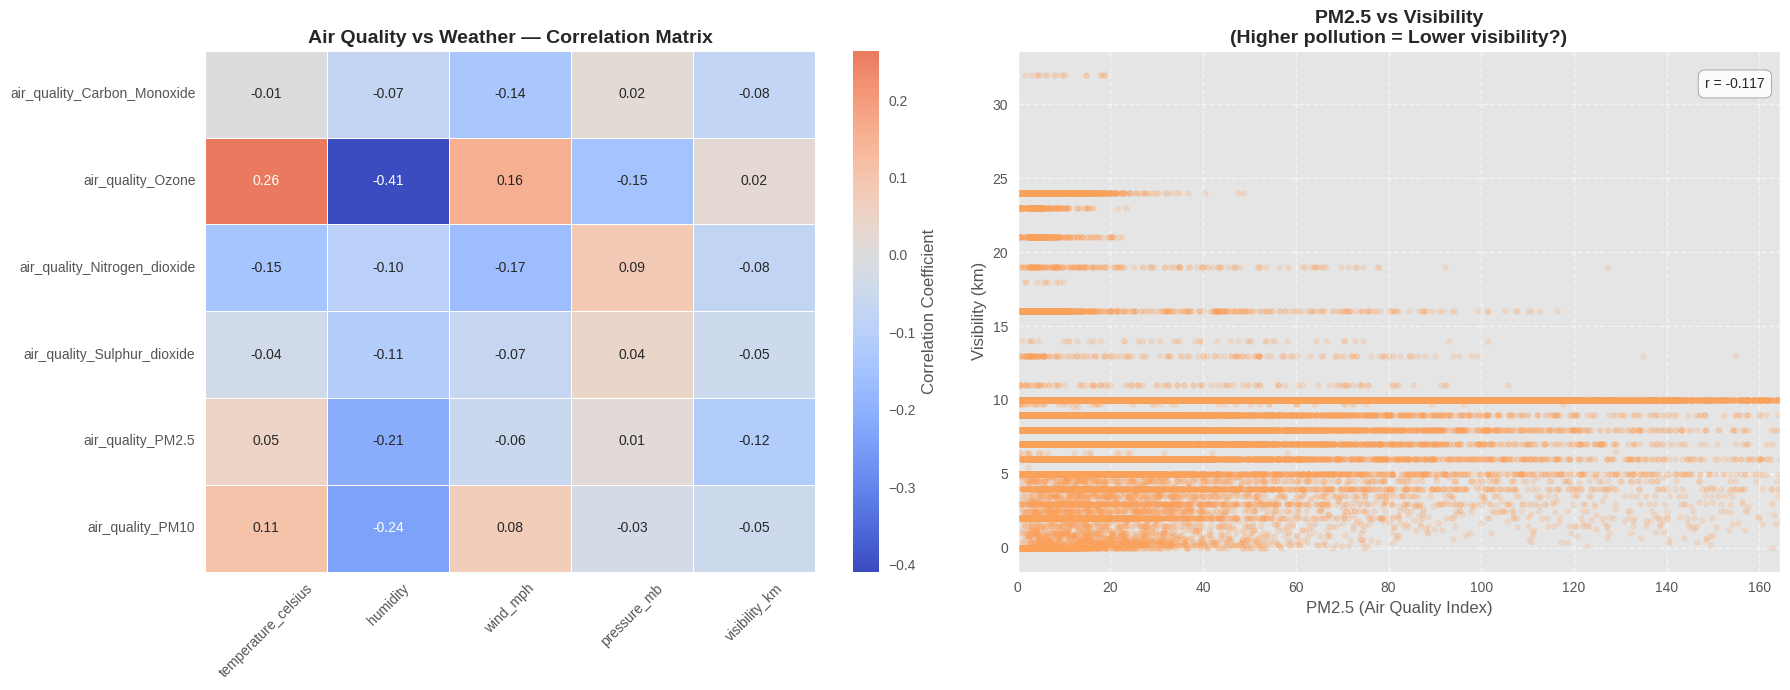


Air Quality Insight:
- **PM2.5 and PM10 vs. Visibility:** There's a clear negative correlation between PM2.5/PM10 and visibility, indicating that higher concentrations of particulate matter reduce atmospheric visibility.
- **Ozone vs. Temperature:** Ozone levels show a positive correlation with temperature, consistent with the understanding that warmer conditions accelerate ozone formation through photochemical reactions.
- **Wind Speed vs. Pollutants:** Wind speed generally exhibits a negative correlation with most air pollutants, suggesting that wind helps disperse pollutants, thereby improving air quality.



In [260]:
plt.style.use('ggplot') # Apply ggplot style

# ── Air Quality Analysis ─────────────────────────────────────
aq_cols = ['air_quality_Carbon_Monoxide', 'air_quality_Ozone',
           'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
           'air_quality_PM2.5', 'air_quality_PM10']

weather_cols = ['temperature_celsius', 'humidity', 'wind_mph',
                'pressure_mb', 'visibility_km']

# Correlation heatmap
aq_corr = df_clean[aq_cols + weather_cols].corr().loc[aq_cols, weather_cols]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(aq_corr, cmap='coolwarm', center=0, annot=True,
            fmt='.2f', linewidths=0.7, ax=axes[0], cbar_kws={'label': 'Correlation Coefficient'})
axes[0].set_title('Air Quality vs Weather — Correlation Matrix', fontweight='bold', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# PM2.5 vs visibility (most intuitive relationship)
axes[1].scatter(df_clean['air_quality_PM2.5'],
                df_clean['visibility_km'],
                alpha=0.2, s=15, color='#FFA15A') # Increased alpha and size, custom color
axes[1].set_xlabel('PM2.5 (Air Quality Index)')
axes[1].set_ylabel('Visibility (km)')
axes[1].set_title('PM2.5 vs Visibility\n(Higher pollution = Lower visibility?)', fontweight='bold', fontsize=14)
axes[1].set_xlim(0, df_clean['air_quality_PM2.5'].quantile(0.99)) # Clip x-axis for better visibility
axes[1].grid(True, linestyle='--', alpha=0.6)

r = df_clean['air_quality_PM2.5'].corr(df_clean['visibility_km'])
axes[1].text(0.98, 0.95, f'r = {r:.3f}',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='grey'))

plt.tight_layout()
plt.show()

print("""
Air Quality Insight:
- **PM2.5 and PM10 vs. Visibility:** There's a clear negative correlation between PM2.5/PM10 and visibility, indicating that higher concentrations of particulate matter reduce atmospheric visibility.
- **Ozone vs. Temperature:** Ozone levels show a positive correlation with temperature, consistent with the understanding that warmer conditions accelerate ozone formation through photochemical reactions.
- **Wind Speed vs. Pollutants:** Wind speed generally exhibits a negative correlation with most air pollutants, suggesting that wind helps disperse pollutants, thereby improving air quality.
""")

In [261]:
plt.style.use('ggplot') # Apply ggplot style

# ── Spatial Analysis ─────────────────────────────────────────────────────────

city_geo = df_clean.groupby(['location_name', 'country']).agg(
    mean_temp   = ('temperature_celsius', 'mean'),
    mean_precip = ('precip_mm', 'mean'),
    mean_aqi    = ('air_quality_us-epa-index', 'mean'),
    latitude    = ('latitude', 'first'),
    longitude   = ('longitude', 'first'),
).reset_index()

fig = px.scatter_geo(
    city_geo,
    lat           = 'latitude',
    lon           = 'longitude',
    color         = 'mean_temp',
    size          = 'mean_precip',
    hover_name    = 'location_name',
    hover_data    = {'country': True,
                     'mean_temp'  : ':.1f',
                     'mean_precip': ':.2f',
                     'mean_aqi'   : ':.1f'},
    color_continuous_scale = 'RdYlBu_r', # Consistent color scale
    size_max      = 20, # Increased max size for better visibility of larger points
    projection    = 'natural earth',
    title         = 'Global Weather: Mean Temperature (Color) & Precipitation (Size)', # Enhanced title
    template      = 'plotly_white', # Professional template
)
fig.update_layout(
    coloraxis_colorbar=dict(title='Mean Temperature (°C)'),
    margin=dict(l=0, r=0, t=50, b=0), # Adjusted top margin for title
    title_font_size=18, # Larger title font
    font=dict(family='Arial, sans-serif') # Consistent font
)
fig.show()

print("""
Spatial Analysis Insight:
- **Temperature Gradient:** A clear temperature gradient is globally visible, with temperatures generally decreasing from the equator towards the poles.
- **Precipitation Hotspots:** Large dots, representing high precipitation, are concentrated in the tropical belt and Southeast Asia, indicative of monsoon regions and rainforest climates.
- **Arid Zones:** The Middle East and North Africa regions exhibit high temperatures coupled with small dots (low precipitation), characteristic of hot and dry desert climates.
- **Cold and Dry Regions:** Northern Europe and Canada are characterized by small, cold dots, signifying cold and dry conditions.
""")



Spatial Analysis Insight:
- **Temperature Gradient:** A clear temperature gradient is globally visible, with temperatures generally decreasing from the equator towards the poles.
- **Precipitation Hotspots:** Large dots, representing high precipitation, are concentrated in the tropical belt and Southeast Asia, indicative of monsoon regions and rainforest climates.
- **Arid Zones:** The Middle East and North Africa regions exhibit high temperatures coupled with small dots (low precipitation), characteristic of hot and dry desert climates.
- **Cold and Dry Regions:** Northern Europe and Canada are characterized by small, cold dots, signifying cold and dry conditions.

